In [66]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np

### Params

In [67]:
path_small = r'TestData/Test256.nii.gz'
path_large = r'TestData/Test512.nii.gz'

### Read in 512 and 1024 images

In [68]:
img_small = sitk.ReadImage(path_small, outputPixelType=sitk.sitkFloat32)
img_large = sitk.ReadImage(path_large, outputPixelType=sitk.sitkFloat32)

In [69]:
def show(image, title=''):

    arr = sitk.GetArrayViewFromImage(image)  # (z, y, x) or (z, y, x, 3) for RGB

    nz, ny, nx = arr.shape[:3]           # ignore trailing channel axis if present
    is_rgb = arr.ndim == 4               # LabelOverlay output is 4D
    cmap = None if is_rgb else 'gray'    # matplotlib needs no cmap for RGB

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    if title:
        fig.suptitle(title, fontsize=12)

    # Center slices
    axes[0, 0].imshow(arr[nz//2, :, :], cmap=cmap); axes[0, 0].set_title(f'Axial (z={nz//2})')
    axes[0, 1].imshow(arr[:, ny//2, :], cmap=cmap); axes[0, 1].set_title(f'Coronal (y={ny//2})')
    axes[0, 2].imshow(arr[:, :, nx//2], cmap=cmap); axes[0, 2].set_title(f'Sagittal (x={nx//2})')

    # MIPs
    axes[1, 0].imshow(np.max(arr, axis=0), cmap=cmap); axes[1, 0].set_title('MIP (axial)')
    axes[1, 1].imshow(np.max(arr, axis=1), cmap=cmap); axes[1, 1].set_title('MIP (coronal)')
    axes[1, 2].imshow(np.max(arr, axis=2), cmap=cmap); axes[1, 2].set_title('MIP (sagittal)')

    plt.tight_layout()
    plt.show()

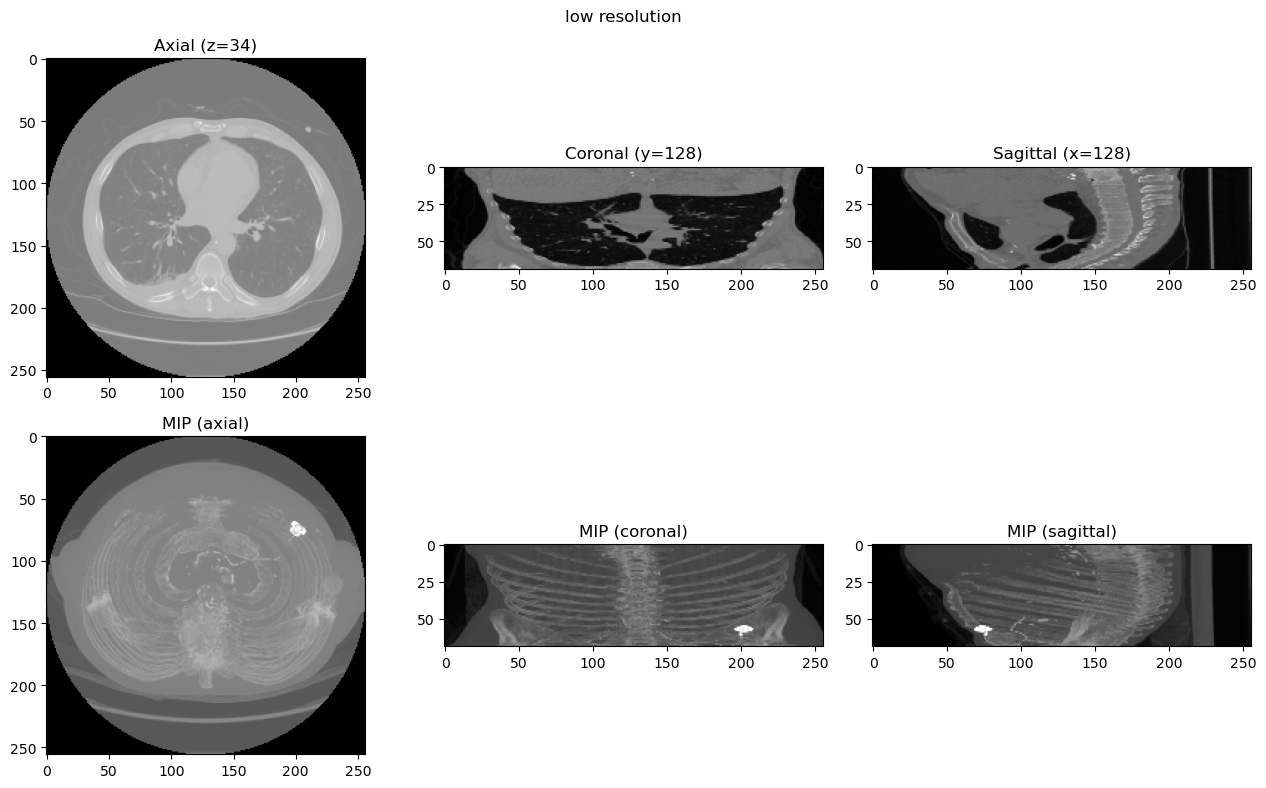

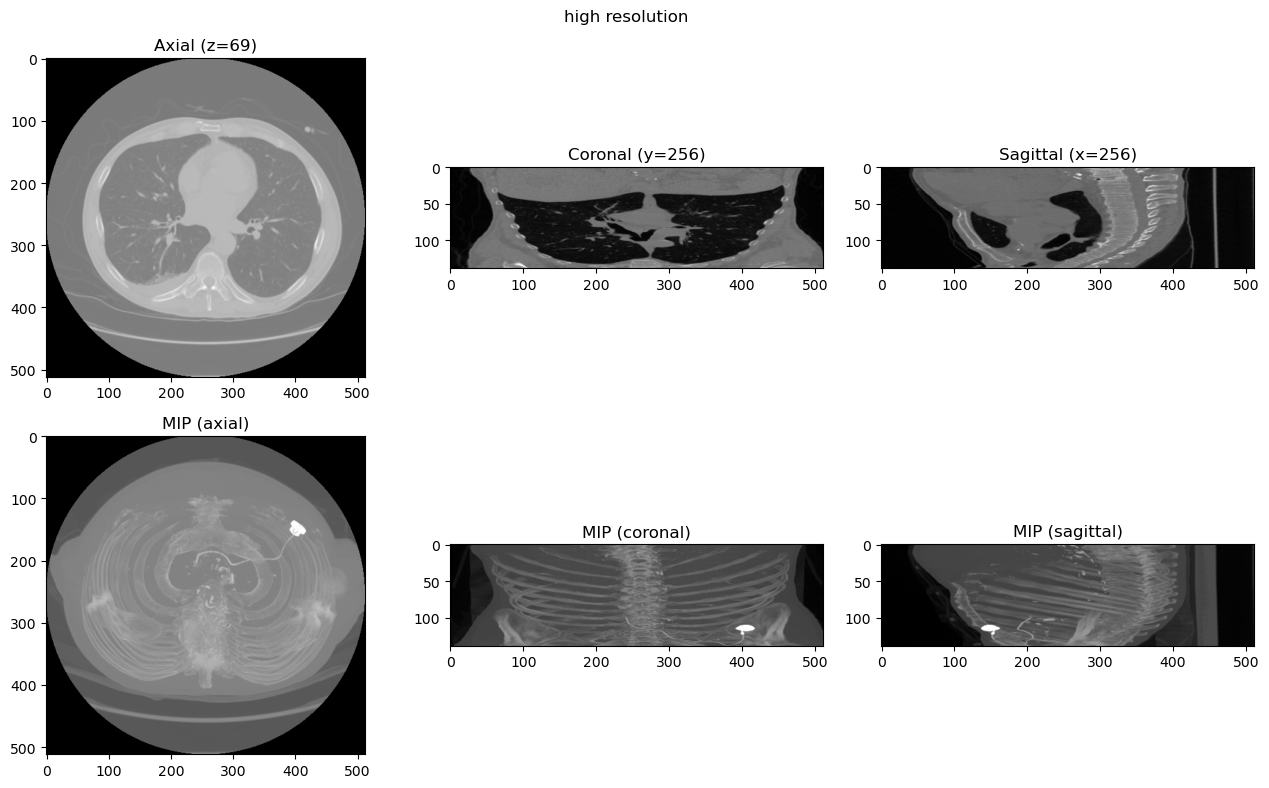

In [70]:
show(img_small, title="low resolution")
show(img_large, title='high resolution')

### Registration

  0 = 2556.44004 : (1.0004991848977953, -2.2027288478880602e-05, 0.00015397444474784473, -3.720896940373312e-05, 1.0005641695299827, 0.00019994405558234322, 0.0001261370654761099, -4.6832446064910616e-05, 1.0002633843042235, 0.2992104946411285, 0.2768596243712868, -2.176102406901242)
  1 = 1938.19701 : (1.0001139205748226, -0.0001241701537530799, 0.00012863601285944287, -0.00017914981215156418, 1.0003045114894689, 0.00020650845253977914, 0.00014908160421671284, -0.00013135168267819347, 1.0003618029959784, -0.027402486044758294, -0.06149522895521218, -2.0062798830556106)
  2 = 1248.03005 : (1.0001577069899148, -7.867077590037256e-05, 0.00016493365915232094, -0.00016876260825383075, 1.0003887626568675, 0.00026847727916650343, 0.00027271665521039684, -0.00026980211357617524, 1.0006700322949749, 0.06581225606504787, 0.07300499047713292, -1.5338176549194837)
  3 =  926.63018 : (0.9998583951532392, -0.00011255861014490341, 0.0001222375038199727, -0.0002634078154684888, 1.0000944207095794, 0.

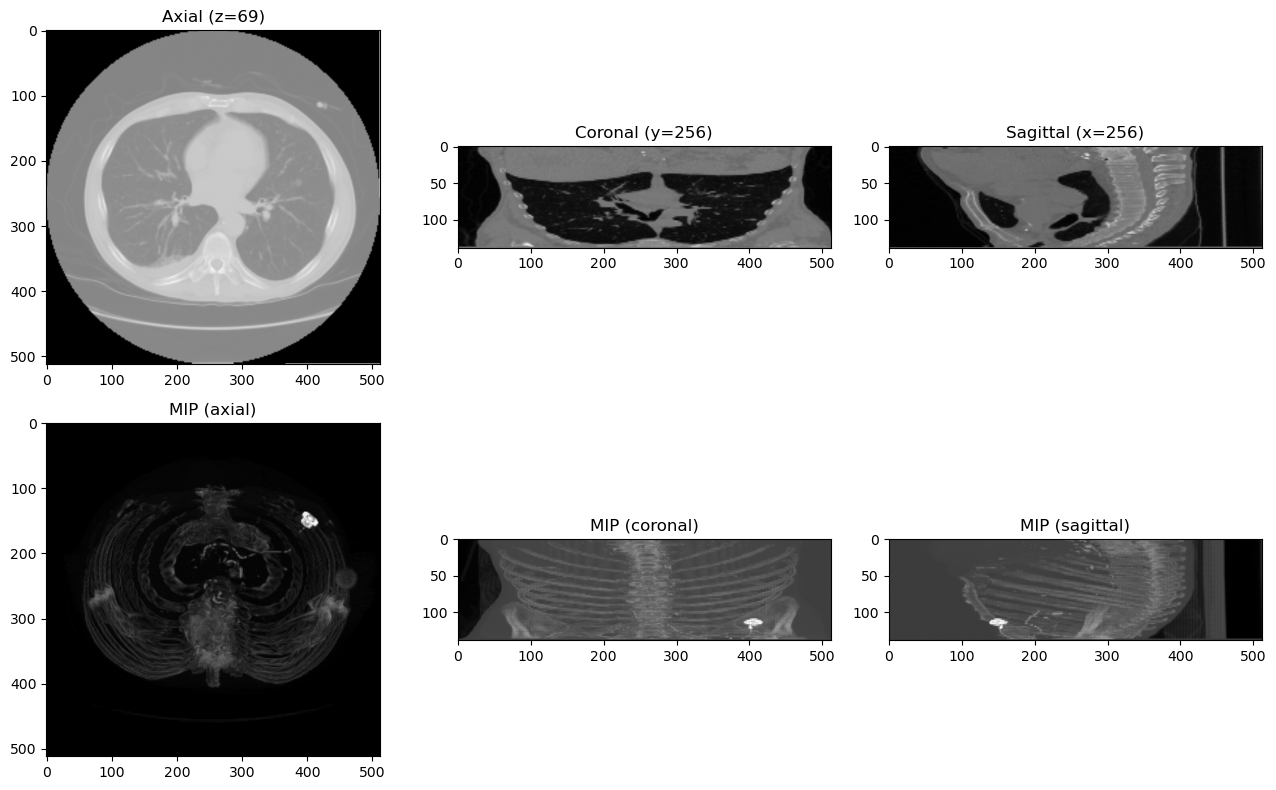

In [71]:
# directly from https://simpleitk.readthedocs.io/en/master/link_ImageRegistrationMethod1_docs.html

def command_iteration(method):
    """ Callback invoked when the optimization process is performing an iteration. """
    print(
        f"{method.GetOptimizerIteration():3} "
        + f"= {method.GetMetricValue():10.5f} "
        + f": {method.GetOptimizerPosition()}"
    )
    
fixed = img_large
moving = img_small
    
R = sitk.ImageRegistrationMethod()
R.SetMetricAsMeanSquares()
R.SetMetricSamplingStrategy(R.RANDOM)
R.SetMetricSamplingPercentage(0.05)

R.SetOptimizerAsRegularStepGradientDescent(
    learningRate=1.0,
    minStep=1e-6,
    numberOfIterations=300,
    gradientMagnitudeTolerance=1e-8,
)
R.SetOptimizerScalesFromPhysicalShift() # weight rotation and translation equally

initial_transform = sitk.CenteredTransformInitializer(
    fixed,
    moving,
    sitk.AffineTransform(3),
    sitk.CenteredTransformInitializerFilter.GEOMETRY,
)

R.SetInitialTransform(initial_transform, inPlace=False)
R.SetInterpolator(sitk.sitkLinear)

R.SetShrinkFactorsPerLevel([4, 2, 1])
R.SetSmoothingSigmasPerLevel([2, 1, 0])
R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

R.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(R))
outTx = R.Execute(fixed, moving)

print("-------")
print(outTx)
print(f"Optimizer stop condition: {R.GetOptimizerStopConditionDescription()}")
print(f" Iteration: {R.GetOptimizerIteration()}")
print(f" Metric value: {R.GetMetricValue()}")

resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(fixed)
resampler.SetInterpolator(sitk.sitkLinear)
resampler.SetDefaultPixelValue(0)
resampler.SetTransform(outTx)
out = resampler.Execute(moving)

show(out)


### Apply transform to mask

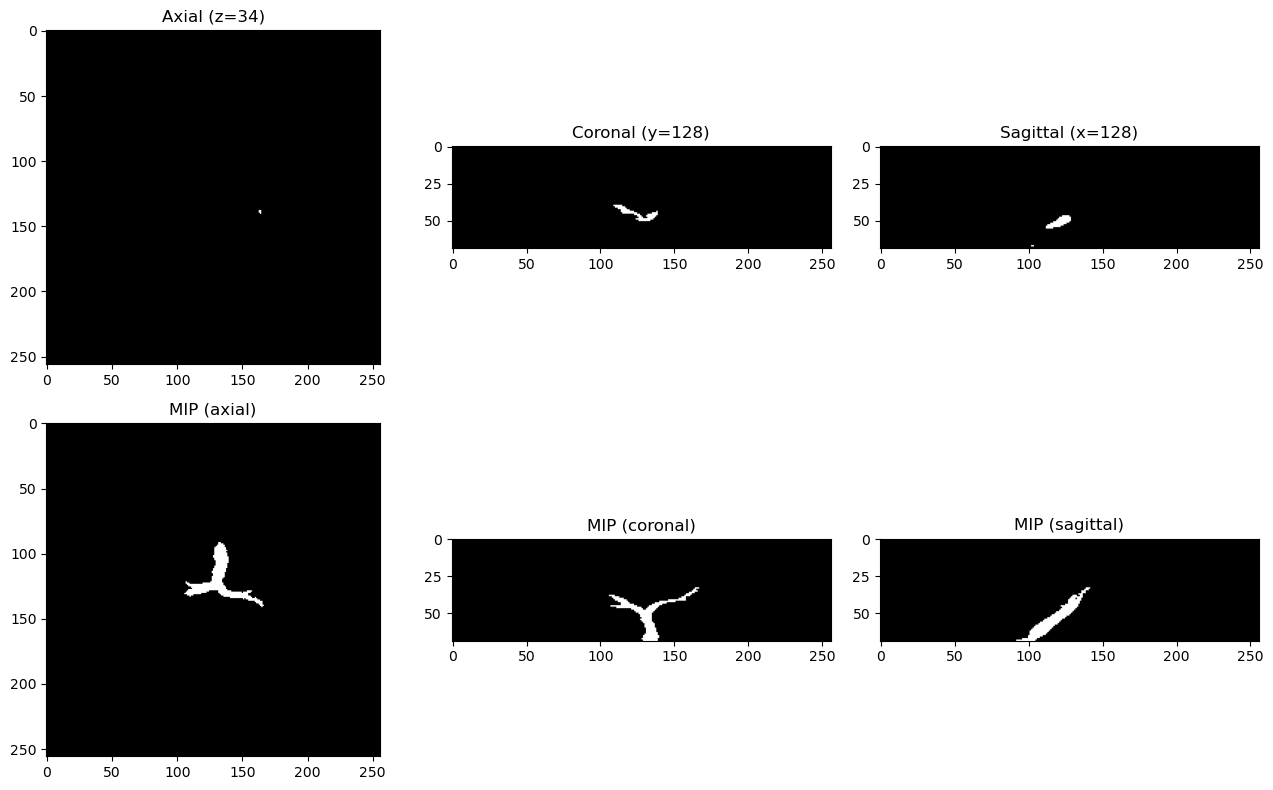

In [72]:
mask_small = sitk.ReadImage(r'TestData/Mask256.nii.gz')
show(mask_small)

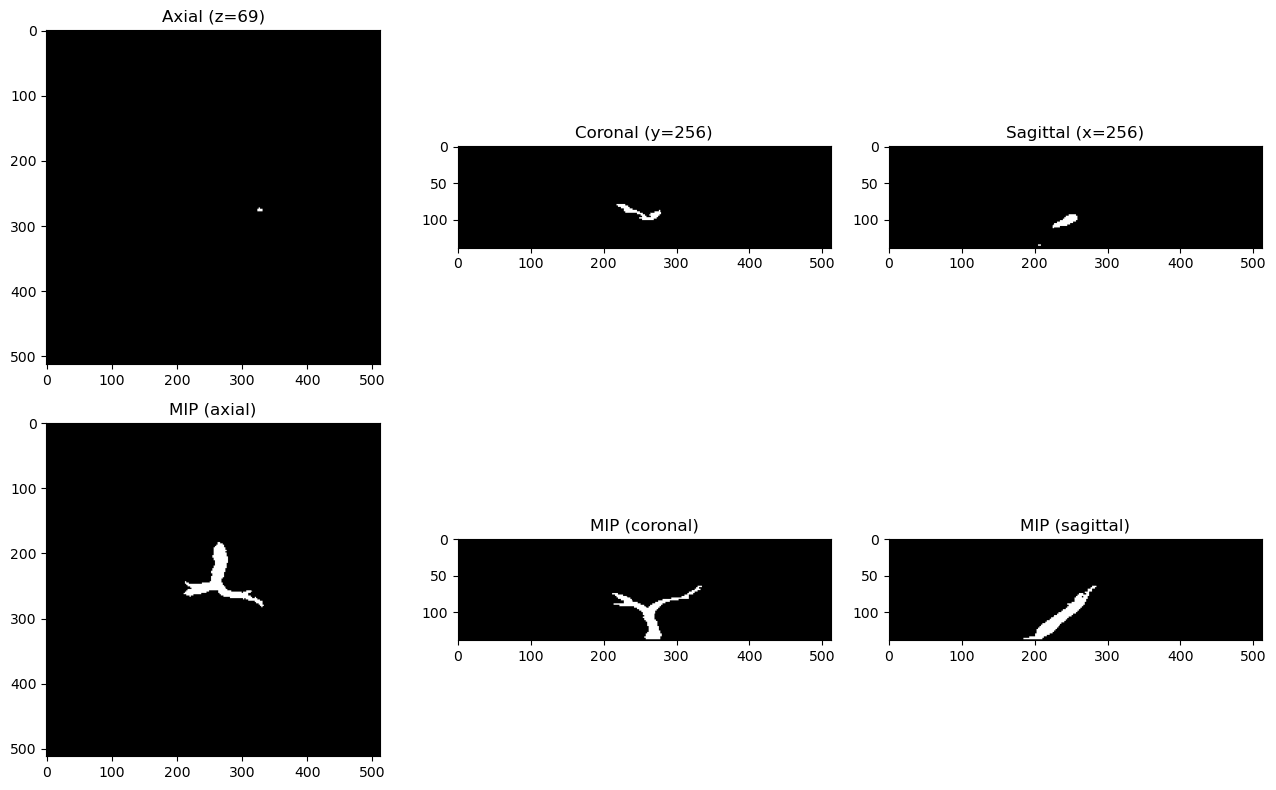

In [73]:
resampler.SetInterpolator(sitk.sitkNearestNeighbor)
mask_large = resampler.Execute(mask_small)
show(mask_large)

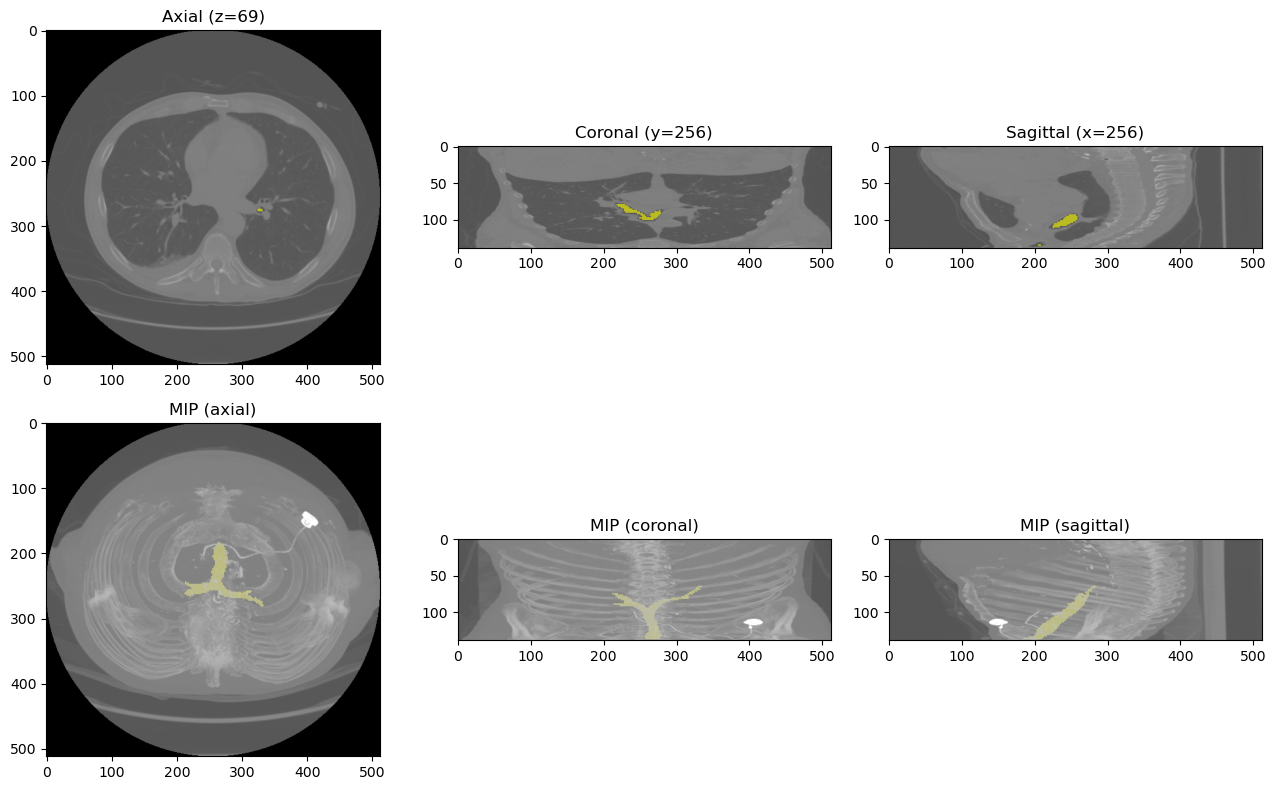

In [74]:
masked_large = sitk.Mask(img_large, mask_large==0)
overlay = sitk.LabelOverlay(
    sitk.Cast(sitk.RescaleIntensity(img_large), sitk.sitkUInt8),
    sitk.Cast(mask_large != 0, sitk.sitkUInt8),
    opacity=0.6,
    colormap=[255, 255, 0]  # label 1 = bright yellow
)
show(overlay)